In [1]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
import astroML.stats

The weather tomorrow depends only on the weather today

Proposal probability:


$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$



$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$



$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$



$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$

In [2]:
#0 is a cloudy day
#1 is a sunny day 

N=100000

def Markov ():
    
    today=0                 #cloudy day 
    cloudy_counts=0
    sunny_counts=0


    #Evolution of the probability for different N 
    Ps=[]              
    Pc=[]


    for i in range(1,N):

        if today ==0:
            p=np.random.uniform(0,1)
            if p<=0.5:
                today=0
            else :
                today=1
        else : 
            p=np.random.uniform(0,1)
            if p<=0.1:
                today=0
            else :
                today=1
        
        if today ==0:
            cloudy_counts+=1
        else :
            sunny_counts+=1
        
        Ps.append(sunny_counts/i)
        Pc.append(cloudy_counts/i)

    return Ps,Pc



After enough days we reach stationarity

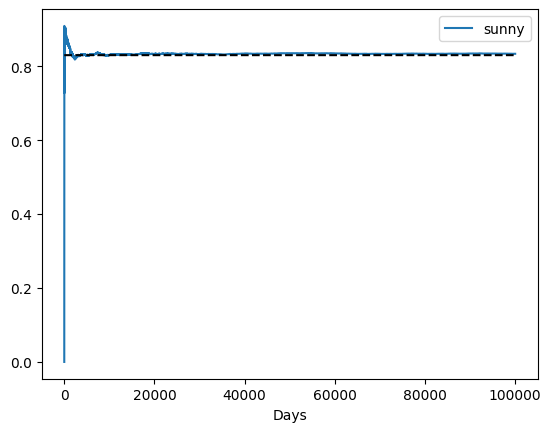

In [3]:
x=np.linspace(1,N,N-1)
Ps=Markov()[0]
plt.plot(x,Ps, label= "sunny")
plt.plot(x,0.83*np.ones(len(x)), '--', color='black') #theoretical value
plt.xlabel("Days")
plt.legend()
plt.show()


Histogram with ALL the points

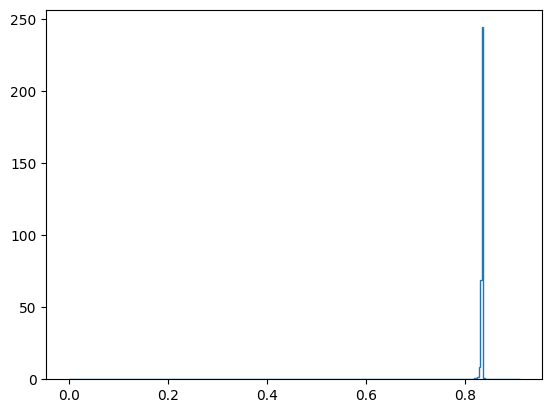

In [4]:
plt.hist(Ps, 300, density=True, histtype='step'); #distribution of P(sunny)

In [ ]:
print(np.median(Ps))
print(astroML.stats.sigmaG(Ps))
print(min(Ps),max(Ps))              #spread of the distribution

0.8338156554707431
0.0007049916995089238
0.0 0.9090909090909091


### Burning phase exploration

Let's cut 20000 points

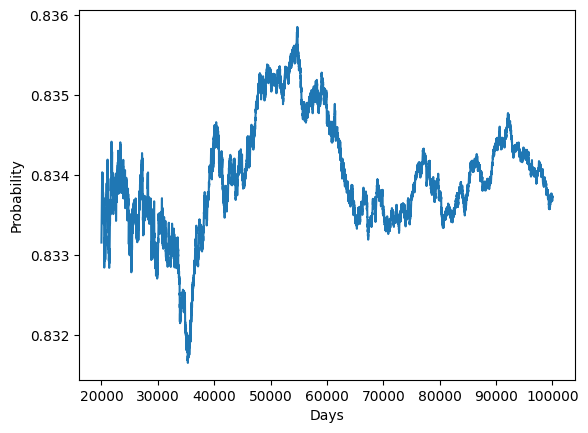

In [6]:
burn = 20000
plt.plot(x[burn:],Ps[burn:])
plt.xlabel("Days")
plt.ylabel("Probability")
plt.show()


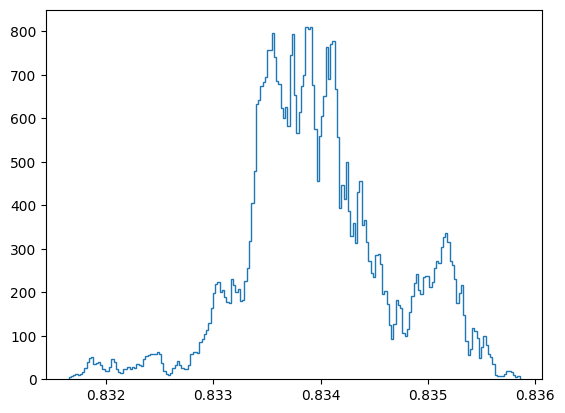

In [7]:
plt.hist(Ps[burn:], 200, density=True, histtype='step'); #distribution of P(sunny)

In [8]:
print(np.median(Ps[burn:]))
print(astroML.stats.sigmaG(Ps[burn:]))
print(min(Ps[burn:]),max(Ps[burn:]))

0.8339056404421327
0.0006065085931770654
0.8316540246801766 0.8358536050843743


### Selection of different parts


In [9]:
Ps1= Ps[40000:60000]
Ps2= Ps[60000:80000]
Ps3= Ps[80000:100000]

print("First slicing is %.4f ± %.4f" %(np.mean(Ps1),np.std(Ps1)))
print("Second slicing is %.4f ± %.4f" %(np.mean(Ps2),np.std(Ps2)))
print("Third slicing is %.4f ± %.4f" %(np.mean(Ps3),np.std(Ps3)))


First slicing is 0.8348 ± 0.0005
Second slicing is 0.8338 ± 0.0004
Third slicing is 0.8340 ± 0.0003


It is stable!


### Performing the chain different times

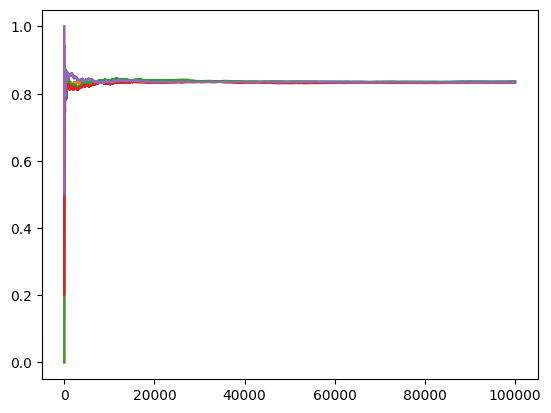

In [10]:
Ps=np.array([Markov()[0] for i in range(5)])
for i in range(5):
    plt.plot(x,Ps[i], label= "sample %d" %i)

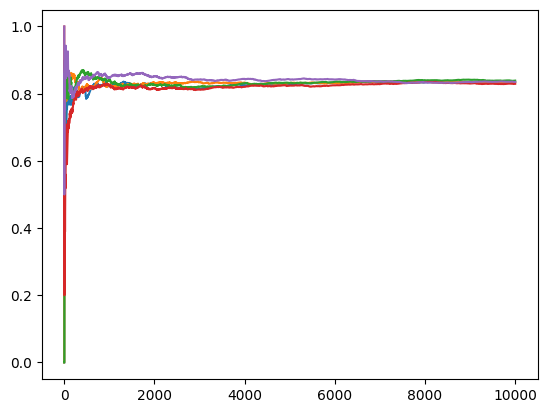

In [11]:
for i in range(5):
    plt.plot(x[:10000],Ps[i][:10000], label= "sample %d" %i)